In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


Model Comparison Results:


,Model,MAE,RMSE,R2
0,Linear Regression,98.905806,530.919390,0.999350
1,Random Forest,112.971885,582.536292,0.999218
2,Decision Tree,120.608536,590.741222,0.999195


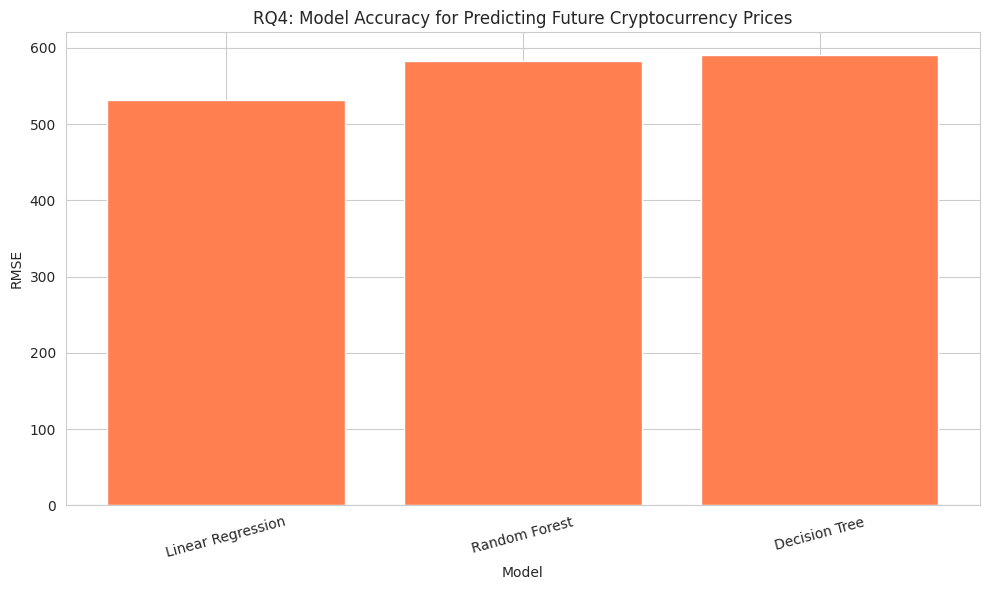

In [10]:
# RQ4: How accurately can machine learning models predict future cryptocurrency prices?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Sort by coin and date
df = df.sort_values(["coin_id", "date"]).reset_index(drop=True)

# Create future price target
df["next_day_price"] = df.groupby("coin_id")["price"].shift(-1)

# Drop rows where future price is unavailable
df = df.dropna(subset=["next_day_price"]).copy()

# Features
feature_cols = [
    "market_cap_rank",
    "price",
    "market_cap",
    "volume",
    "daily_return",
    "price_ma7",
    "price_ma30",
    "volatility_7d",
    "cumulative_return"
]

model_df = df[["date", "next_day_price"] + feature_cols].copy()

# Time-based split
unique_dates = sorted(model_df["date"].unique())
split_index = int(len(unique_dates) * 0.80)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

train_df = model_df[model_df["date"].isin(train_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["next_day_price"]
y_test = test_df["next_day_price"]

# Models
models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(max_depth=6, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Save table
results_df.to_csv("/kaggle/working/RQ4_model_results.csv", index=False)

print("Model Comparison Results:")
display(results_df)

# Figure
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"], color="coral")
plt.title("RQ4: Model Accuracy for Predicting Future Cryptocurrency Prices")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/RQ4_models.pdf")
plt.show()
